# Error Correction Model Parameter Scan

Consider two cointegrated time series, $X_t \sim I(1)$ and $Y_t \sim I(1)$. The Error Correction Model is given by,

$
\begin{align}
\Delta Y_t = \delta + \gamma \Delta X_t + \lambda \left( Y_{t-1} - \alpha - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{11}
$

For simplicity it will be assumed that $\alpha = \delta = 0$ giving,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{12}
$

Here the behavior of solutions to the ECM will be discussed as the parameters $\beta$, $\lambda$ and $\gamma$ are variated. Also, the variation in the $\text{AR}(1)$ coefficient $\varphi$, used in the simulation of $X_t$ will be considered.

## Mean Variance and Covariance

The mean, variance and variance of the ECM variable $X_t$ is given by,

$
\begin{align}
\text{E}\left[ X_t\right] &= 0 \\
\text{Var}\left[ X_t\right] &= \frac{\sigma^2}{1 - \varphi^2}\left[t + 2 \sum_{k=1}^t \left(t - k\right) \varphi^k \right]
\end{align}
\tag{14}
$

and for $Y_t$,

$
\begin{align}
\text{E}\left[ Y_t\right] &= 0 \\
\text{Var}\left[ Y_t\right] &= \beta^2 \text{Var}\left[ X_t\right]
\end{align}
\tag{15}
$

Finally the covariance of $X_t$ and $Y_t$ is given by,

$
\begin{align}
\text{Cov}\left[X_t Y_t\right] &= \beta \text{Var}\left[ X_t\right]
\end{align}
\tag{16}
$

In [4]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import ecm_beta, comparison

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [14]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

## $\beta$ Scan

Insight into variation of $\beta$ can be determined by inspecting expressions for the variance and covariance for $X_t$ and $Y_t$. First consider the variance,

$
\begin{align}
\text{E}\left[ Y_t\right] &= 0 \\
\text{Var}\left[ Y_t\right] &= \beta^2 \text{Var}\left[ X_t\right]
\end{align}
\tag{15}
$

For $|\beta| \gt 1$ it follows that $\text{Var}\left[ Y_t\right] \gt \text{Var}\left[ X_t\right]$, for $|\beta| \lt 1$ it follows that $\text{Var}\left[ Y_t\right] \lt \text{Var}\left[ X_t\right]$ and if $|\beta| = 1$ the variances of $X_t$ and $Y_t$ are equal. From the covariance relationship,

$
\begin{align}
\text{Cov}\left[X_t Y_t\right] &= \beta \text{Var}\left[ X_t\right]
\end{align}
\tag{16}
$

it is seen for $\beta \gt 0$ that $X_t$ and $Y_t$ are correlated, for $\beta \lt 0$ they are negatively correlated and if $\beta = 0$ they are uncorrelated.

In [6]:
φ = 0.5
λ = -0.5
γ = 0.5
npts = 1000

### $\beta=0$

$X_t$ and $Y_t$ are uncorrelated as seen in the regression plot and $\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}$ implies that $\varepsilon_{t-1} = Y_{t-1}$

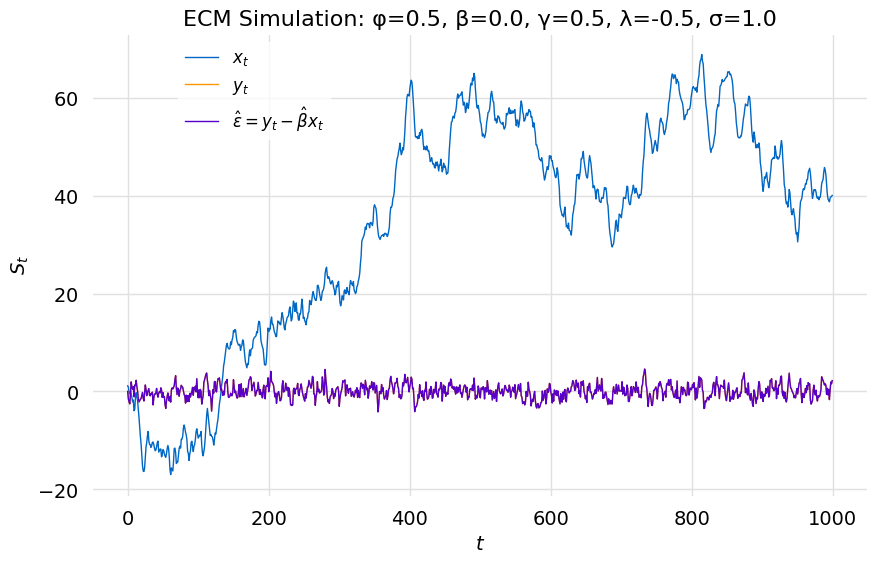

In [15]:
β = 0.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [8]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4843
Date:                Sun, 01 Oct 2023   Prob (F-statistic):              0.487
Time:                        12:45:48   Log-Likelihood:                -1790.4
No. Observations:                1000   AIC:                             3585.
Df Residuals:                     998   BIC:                             3595.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2266      0.095      2.383      0.017       0.040       0.413
x1             0.0008      0.001      0.696      0.487      -0.001       0.003
==============================================================================
Omnibus:                        0.731   Durbin-Watson:                   0.730
Prob(Omnibus):                  0.694   Jarque-Bera (JB):                0.720
Skew:                          -0.066   Prob(JB):                        0.698
Kurtosis:                       2.992   Cond. No.                         182.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

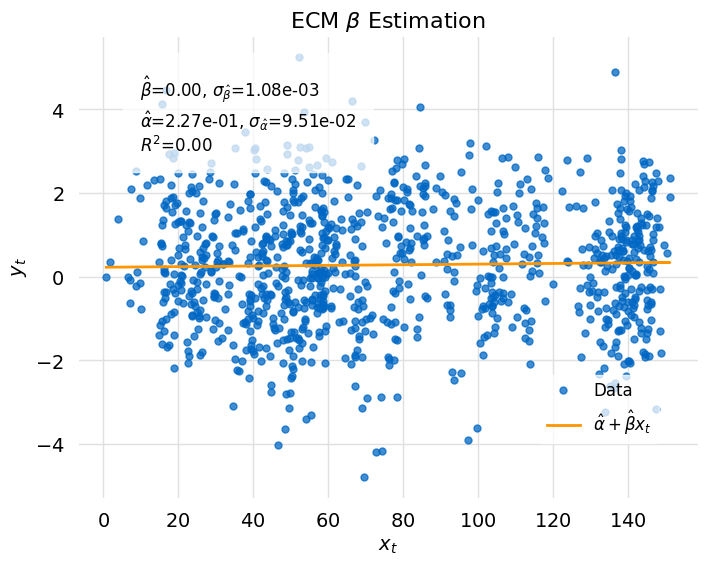

In [9]:
ecm_beta(yt, result_model, xt)

### $\beta=1$

$X_t$ and $Y_t$ correlated with equal variance

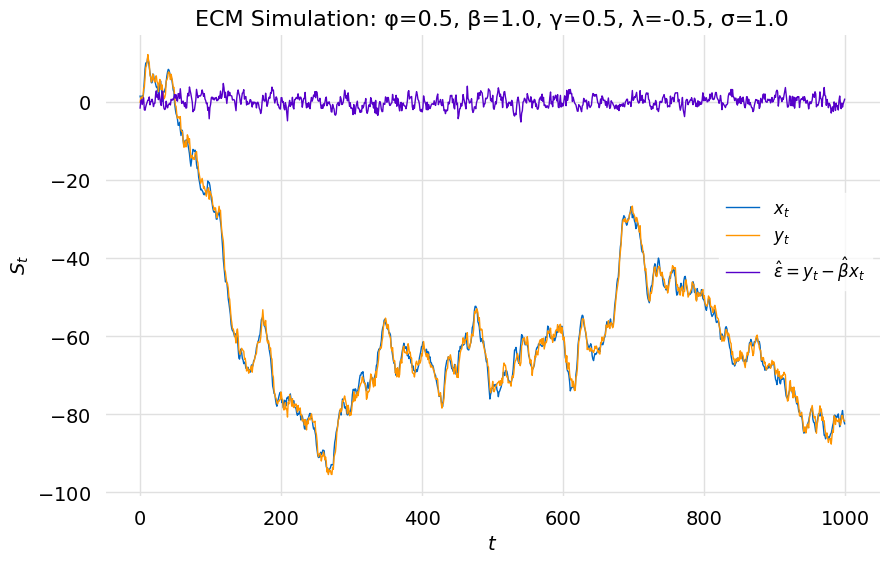

In [23]:
β = 1.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [24]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.403e+05
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:11:53   Log-Likelihood:                -1791.7
No. Observations:                1000   AIC:                             3587.
Df Residuals:                     998   BIC:                             3597.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3745      0.128      2.928      0.003       0.124       0.626
x1             1.0044      0.002    490.195      0.000       1.000       1.008
==============================================================================
Omnibus:                        0.450   Durbin-Watson:                   0.740
Prob(Omnibus):                  0.799   Jarque-Bera (JB):                0.418
Skew:                          -0.050   Prob(JB):                        0.811
Kurtosis:                       3.009   Cond. No.                         174.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

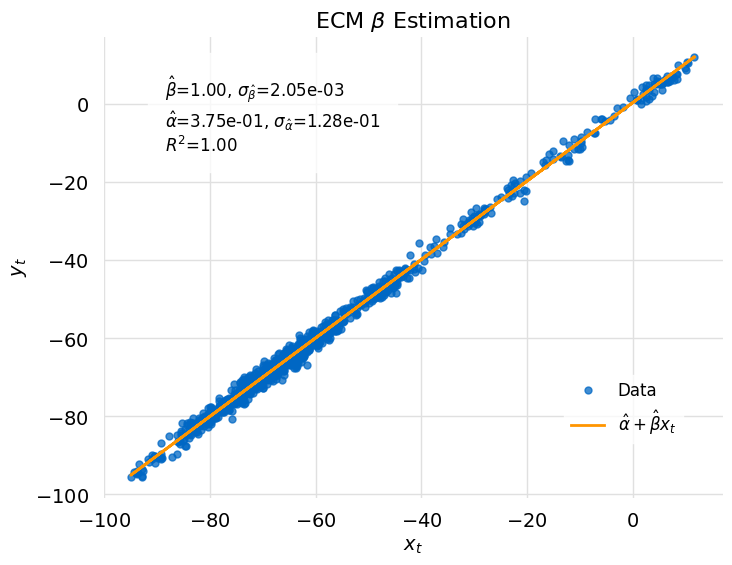

In [25]:
ecm_beta(yt, result_model, xt)

### $\beta=-1$

$X_t$ and $Y_t$ uncorrelated with equal variance.

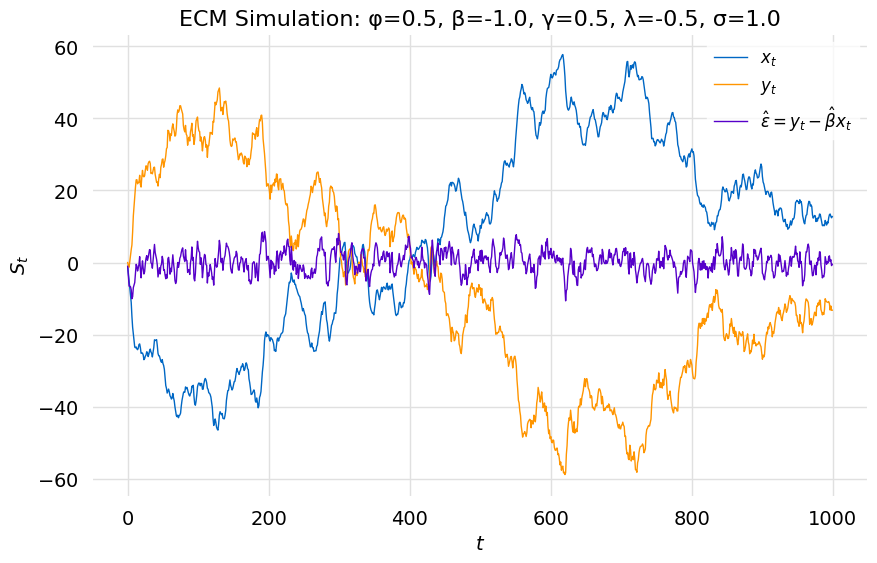

In [26]:
β = -1.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [27]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 8.048e+04
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:12:59   Log-Likelihood:                -2533.1
No. Observations:                1000   AIC:                             5070.
Df Residuals:                     998   BIC:                             5080.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0413      0.100      0.414      0.679      -0.155       0.237
x1            -0.9932      0.004   -283.682      0.000      -1.000      -0.986
==============================================================================
Omnibus:                        5.380   Durbin-Watson:                   0.421
Prob(Omnibus):                  0.068   Jarque-Bera (JB):                5.251
Skew:                          -0.170   Prob(JB):                       0.0724
Kurtosis:                       3.100   Cond. No.                         29.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

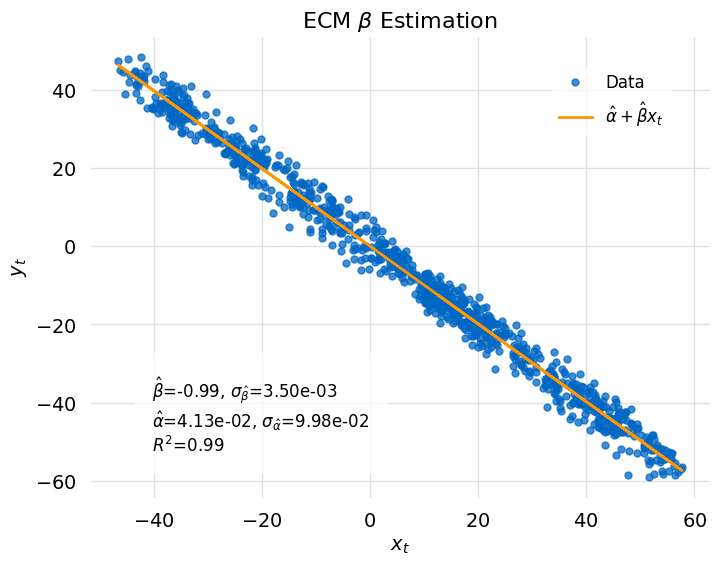

In [28]:
ecm_beta(yt, result_model, xt)

### $\beta \lt 0$, $\beta \gt 0$ and $|\beta | \lt 1$

The first plots show $\beta \lt 0$ where $X_t$ and $Y_t$ are uncorrelated and $\text{VAR}\left[X_t\right] > \text{VAR}\left[Y_t\right]$ and second plots show $\beta \gt 0$ where $X_t$ and $Y_t$ are correlated and $\text{VAR}\left[X_t\right] > \text{VAR}\left[Y_t\right]$ 

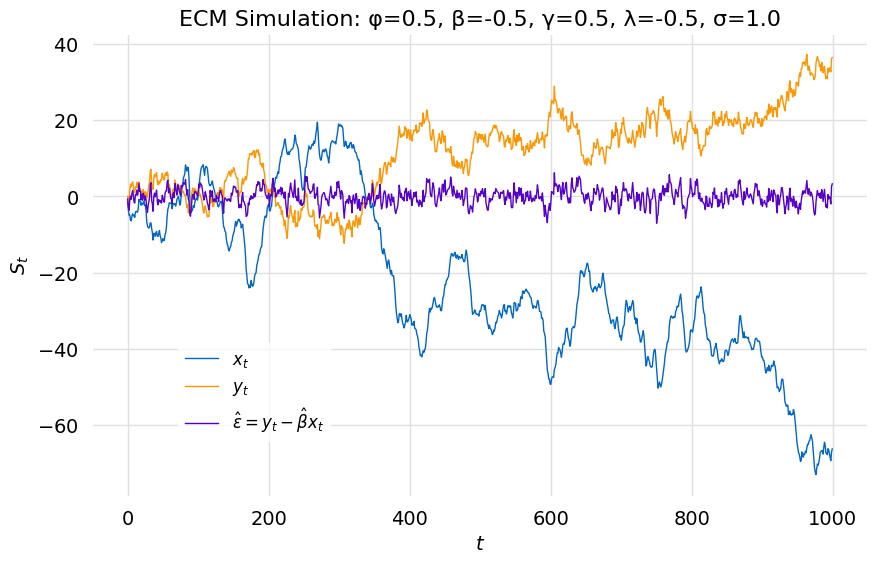

In [16]:
β = -0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [17]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 2.574e+04
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:01:35   Log-Likelihood:                -2141.6
No. Observations:                1000   AIC:                             4287.
Df Residuals:                     998   BIC:                             4297.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1978      0.096      2.071      0.039       0.010       0.385
x1            -0.4903      0.003   -160.444      0.000      -0.496      -0.484
==============================================================================
Omnibus:                        2.401   Durbin-Watson:                   0.632
Prob(Omnibus):                  0.301   Jarque-Bera (JB):                2.257
Skew:                          -0.099   Prob(JB):                        0.324
Kurtosis:                       3.122   Cond. No.                         45.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

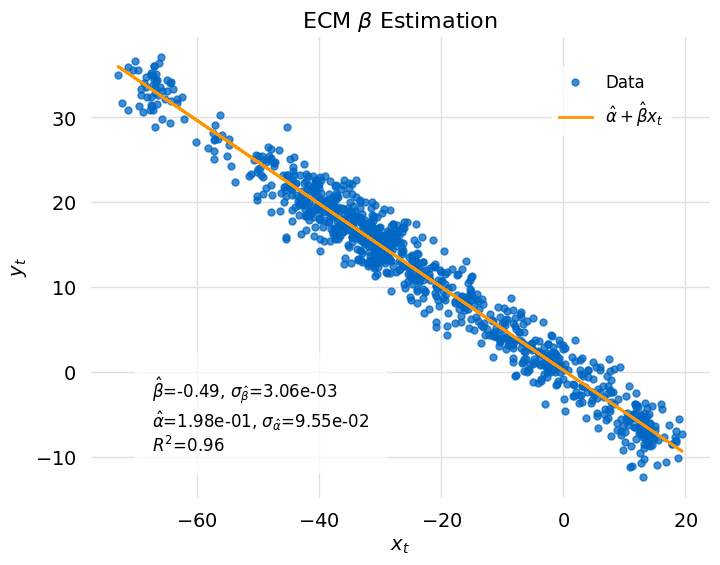

In [19]:
ecm_beta(yt, result_model, xt)

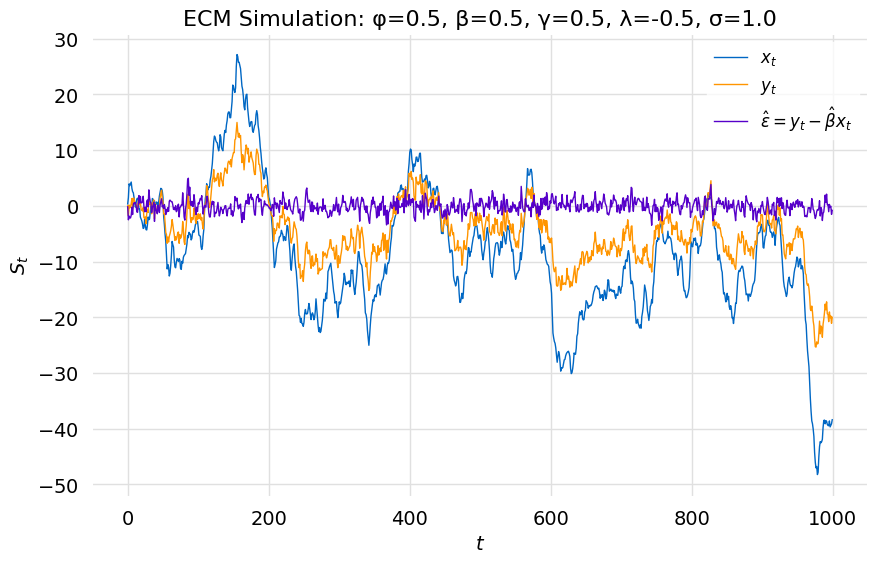

In [29]:
β = 0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [30]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 2.608e+04
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:13:28   Log-Likelihood:                -1570.9
No. Observations:                1000   AIC:                             3146.
Df Residuals:                     998   BIC:                             3156.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0252      0.046     -0.552      0.581      -0.115       0.064
x1             0.5021      0.003    161.505      0.000       0.496       0.508
==============================================================================
Omnibus:                       11.538   Durbin-Watson:                   1.037
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               14.600
Skew:                           0.148   Prob(JB):                     0.000676
Kurtosis:                       3.513   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

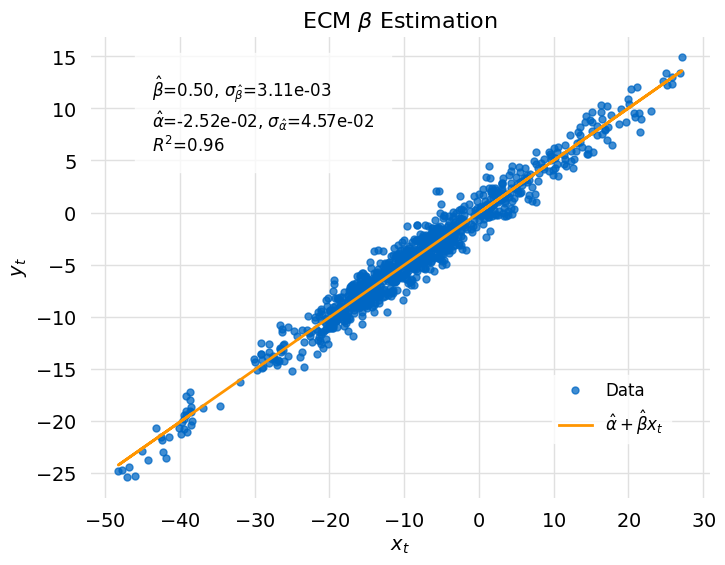

In [31]:
ecm_beta(yt, result_model, xt)

### $\beta \lt 0$, $\beta \gt 0$ and $|\beta | \gt 1$

The first plots show $\beta \lt 0$ where $X_t$ and $Y_t$ are uncorrelated and $\text{VAR}\left[X_t\right] < \text{VAR}\left[Y_t\right]$ and second plots show $\beta \gt 0$ where $X_t$ and $Y_t$ are correlated and $\text{VAR}\left[X_t\right] < \text{VAR}\left[Y_t\right]$ 

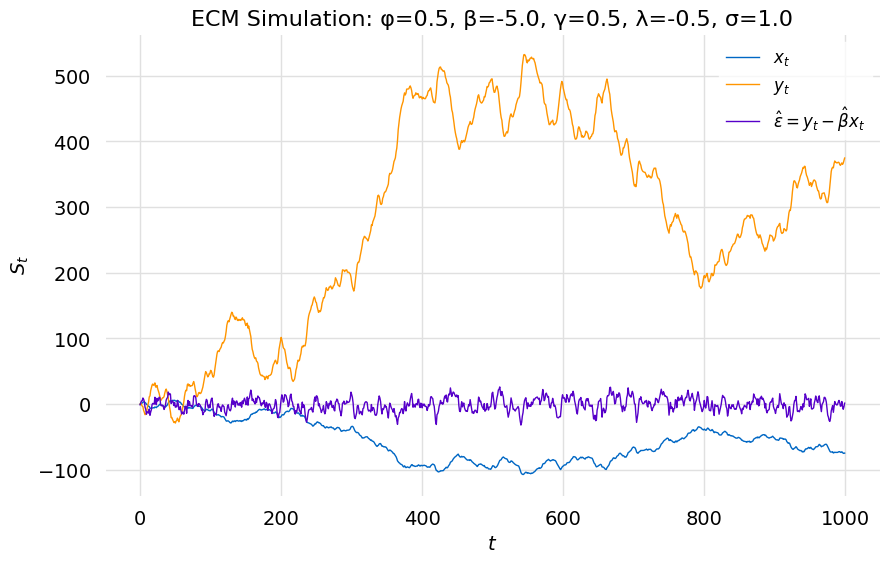

In [32]:
β = -5.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [33]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.576e+05
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:23:07   Log-Likelihood:                -3706.2
No. Observations:                1000   AIC:                             7416.
Df Residuals:                     998   BIC:                             7426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9806      0.632     -1.551      0.121      -2.221       0.260
x1            -5.0036      0.010   -507.520      0.000      -5.023      -4.984
==============================================================================
Omnibus:                        3.294   Durbin-Watson:                   0.373
Prob(Omnibus):                  0.193   Jarque-Bera (JB):                3.363
Skew:                          -0.135   Prob(JB):                        0.186
Kurtosis:                       2.913   Cond. No.                         130.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

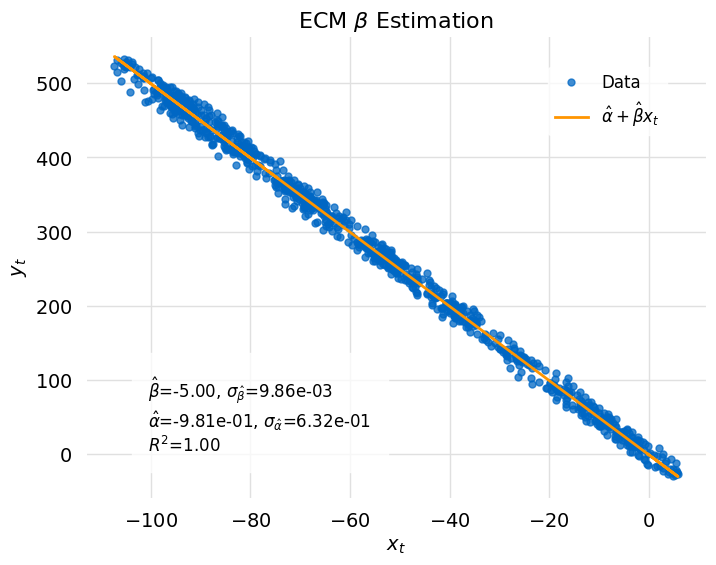

In [34]:
ecm_beta(yt, result_model, xt)

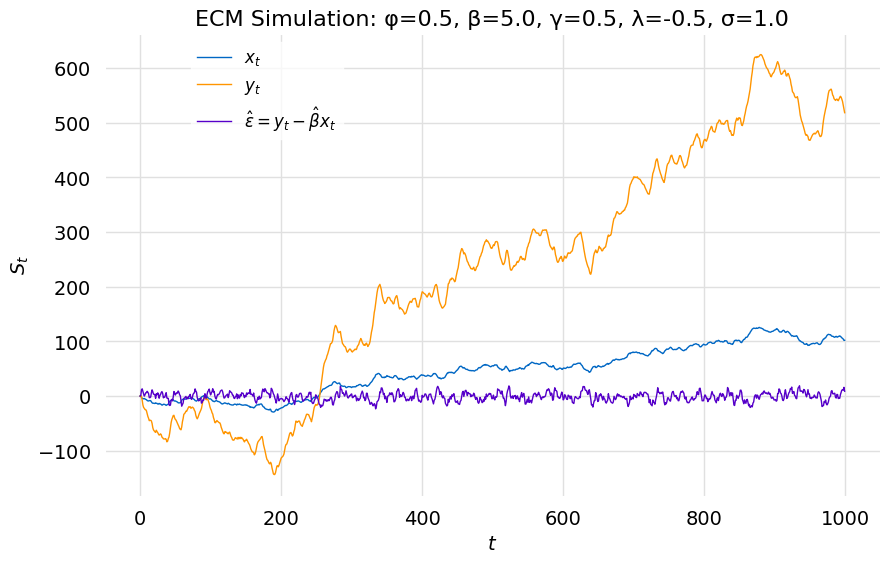

In [35]:
β = 5.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [36]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 8.058e+05
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:23:42   Log-Likelihood:                -3453.7
No. Observations:                1000   AIC:                             6911.
Df Residuals:                     998   BIC:                             6921.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6379      0.354     -1.804      0.072      -1.332       0.056
x1             4.9929      0.006    897.662      0.000       4.982       5.004
==============================================================================
Omnibus:                        6.148   Durbin-Watson:                   0.408
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                5.310
Skew:                          -0.108   Prob(JB):                       0.0703
Kurtosis:                       2.716   Cond. No.                         92.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

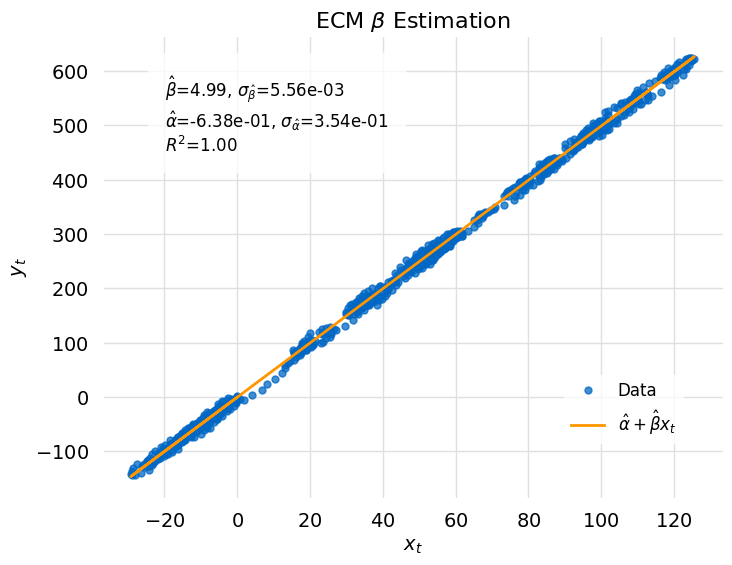

In [37]:
ecm_beta(yt, result_model, xt)

## $\lambda$ Scan

The values of $\lambda$ and $\gamma$ measure the relative weighting of the $\Delta X_t$ term and the error correction term, $Y_{t-1} - \beta X_{t-1}$.

Transitions in the qualitative behavior of simulations for the following values,

$
\begin{align}
\lambda = 0, -1, -2
\end{align}
\tag{16}
$

/Users/troy/Develop/gly.fish/alef/lib/models/ecm.py:122: RuntimeWarning: overflow encountered in scalar multiply
  Δyt = δ + γ*Δxt + λ*(yt[i-1] - α - β*xt[i-1]) + ξt[i]
/Users/troy/.pyenv/versions/3.11.2/envs/alef-3.11.2/lib/python3.11/site-packages/matplotlib/ticker.py:2094: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


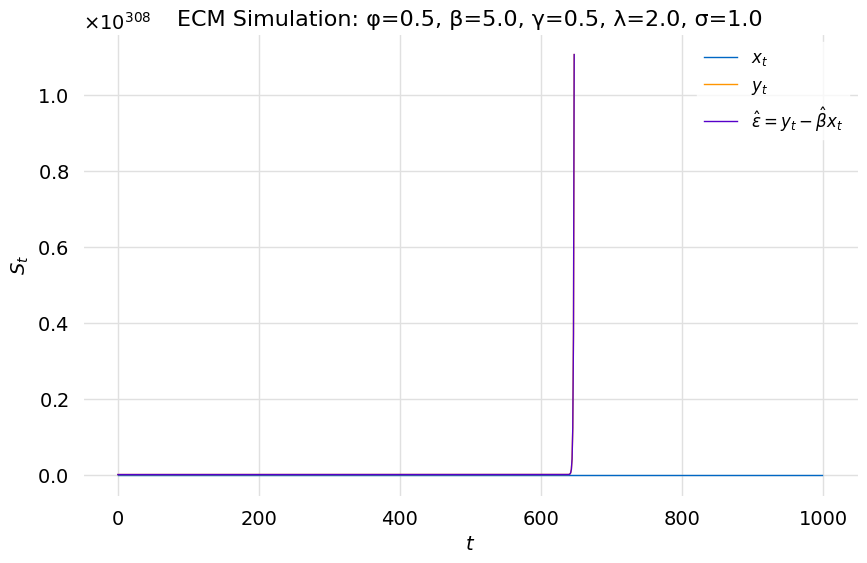

In [47]:
β = 5.0
φ = 0.5
λ = 2.0
γ = 0.5

t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [ ]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 8.058e+05
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:23:42   Log-Likelihood:                -3453.7
No. Observations:                1000   AIC:                             6911.
Df Residuals:                     998   BIC:                             6921.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6379      0.354     -1.804      0.072      -1.332       0.056
x1             4.9929      0.006    897.662      0.000       4.982       5.004
==============================================================================
Omnibus:                        6.148   Durbin-Watson:                   0.408
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                5.310
Skew:                          -0.108   Prob(JB):                       0.0703
Kurtosis:                       2.716   Cond. No.                         92.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""